# Einführung in NumPy

**_NumPy_** ist eine Programmbibliothek für die Programmiersprache Python, die eine einfache Handhabung von Vektoren, Matrizen oder generell großen mehrdimensionalen Arrays ermöglicht. Neben den Datenstrukturen bietet **_NumPy_** auch effizient implementierte Funktionen für numerische Berechnungen mit mehrdimensionalen Arrays an. 

Referenzen:
- [Wikipedia - Numpy](https://de.wikipedia.org/wiki/NumPy)
- Numpy Homepage https://numpy.org/

2026-05-03 ug Version 1.9

----
### Vorbereitung 
Das `numpy` - Pakete wird durch folgenden Befehl geladen und vereinfacht als `np` abgekürzt:
```Python
import numpy as np
```
Dieses Abkürzen nennt sich _aliasing_ in Python. Dadurch wird der Schreibaufwand reduziert, aber die Zuordnung zu welchem Paket ein Konstrukt gehört, bleibt weiter erkennbar.

**Bitte _nicht_ verwenden**:
```Python
from numpy import *
```
Hier ist der Schreibaufwand am geringsten, aber die Zuordung geht dabei verloren.


In [1]:
import numpy as np

Ausgabe der installierten Version von numpy

In [2]:
np.__version__

'2.4.3'

----
## Motivation: Warum die Verwendung von NumPy sinnvoll ist


**Beispiel-Aufgabe**: 
Die beiden Vektoren $v_1=(1,2,3,4)$ und $v_2=(10,20,30,40)$ sollen elementweise addiert werden.

### Python - klassisch mit Listen

Klassisch können in **Python** Vektoren als Listen angelegt werden:

In [3]:
v1=[1,2,3,4]
v1

[1, 2, 3, 4]

In [4]:
v2=[10,20,30,40]
v2

[10, 20, 30, 40]

Für Listen liefert der `+` Operator in Standard Python jedoch nicht die elementweise Summe, sondern bewirkt ein Aneinanderhängen der Listen:

In [5]:
v1+v2

[1, 2, 3, 4, 10, 20, 30, 40]

Das ist nicht das Ergebnis, das wir haben wollen.

Wir können eine `for` Schleife nutzen, um die entsprechenden Elemente beider Listen zu addieren:

In [6]:
ergebnis = []
for idx in range(min(len(v1),len(v2))):
    ergebnis.append(v1[idx] + v2[idx])
ergebnis

[11, 22, 33, 44]

Mit `min(len(v1),len(v2))` kann ich auch Fälle bearbeiten, bei denen die Vektoren unterschiedlich lang sind.

Vereinfachung durch den Einsatz der in Python eingebauten Funktion `zip()`

In [7]:
ergebnis = []
for element1,element2 in zip(v1,v2):
    ergebnis.append(element1+element2)
ergebnis

[11, 22, 33, 44]

Anmerkung: Was macht die Funktion `zip()`?

Die Anwendung der Funktion `zip()` gibt einen Iterator zurück, der in der Lage ist, nacheinander Tupels zu erzeugen. 
<br>
Es werden die ersten Elemente der iterierbaren Parameter (in unseren Beispiel handelt es sich am Listen) zu einem Tupel zusammengefasst, danach werden die zweiten Elemente zusammengefügt, dann die dritten und so weiter. Die Funktion `zip()` stoppt, wenn einer der Parameter am Ende ist, d.h. es sind keine weiteren Elemente verfügbar; siehe [www.python-kurs.eu - python3 zip tutorial ](https://www.python-kurs.eu/python3_zip_tutorial.php).
<br>
Ähnlich einem Reißverschluss  (engl. zipper), bestehend zwei Seitenteilen mit Krampen und einem Schieber, der die Krampen ineinander verhakt.


In [8]:
zip(v1,v2)

`zip(v1, v2)` liefert einen Iterator für Tuples, nicht Tuples selber, siehe [Python zip function - weird result - stackoverflow](https://stackoverflow.com/questions/41386943/python-zip-function-weird-result).

Dies nennt man _lazy  evaluation_ in Python, siehe [Lazy evaluation in Python - stackoverflow](https://stackoverflow.com/questions/20535342/lazy-evaluation-in-python).

`zip()` liefert ein Objekt vom Typ _zip_:

In [9]:
type(zip(v1,v2))

zip

Wenn ich explizit die Erzeugung einer Liste mit `list()` anfordere, dann erzeugt Python eine Liste mit Tuples der ensprechenden Elemente:

In [10]:
list(zip(v1,v2))

[(1, 10), (2, 20), (3, 30), (4, 40)]

#### _List Comprehensions_ zur elementweisen Addition zweier Vektoren

Einsatz von _List Comprehensions_ als alternative Lösung zur elementweisen Addition zweier Vektoren:

In [11]:
[element1+element2 for element1,element2 in zip(v1,v2)]

[11, 22, 33, 44]

### Numpy - Einsatz von Feldern (Arrays)

So sieht die Lösung der elementweisen Addition zweier Vektoren in **NumPy** aus:

Die Vektoren $v_1$ und $v_2$ werden jeweils als _Numpy Arrays_ `np.array()` angelegt:

In [12]:
v1_np = np.array(v1)
v1_np

array([1, 2, 3, 4])

In [14]:
type(v1_np)

numpy.ndarray

In [13]:
v2_np = np.array(v2)
v2_np

array([10, 20, 30, 40])

Der `+` Operator liefert für _Numpy Arrays_ die elementweise Summen:

In [15]:
v1_np + v2_np

array([11, 22, 33, 44])

**Geschwindigkeitsvergleich:** Aufsummieren der Zahlen von 0 bis 9999

a) klassisch in Python

In [16]:
v1 = list(range(10000))
len(v1)

10000

In [17]:
%timeit sum(v1)

55.1 μs ± 269 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


b) mit Numpy

In [18]:
v1_np = np.array(v1)
v1_np

array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(10000,))

In [19]:
%timeit np.sum(v1_np)

4.16 μs ± 47.3 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


_**Numpy**_ ist circa eine Größenordnung schneller als _**Python**_:
- Python: (2026: 51.5 μs) (2025: 73.3 μs) (2024: 56.1µs) (2023: 78.8 µs)
- Numpy: (2026: 3.74 μs) (2025: 7.5 µs) (2024: 10.6 µs) (2023: 9.28 µs)

Anmerkung zu `%timeit`:

`%timeit` ist eine _iPython magic_ Anweisung, die es nur im Jupyter Notebook (genauer in iPython) gibt und die zum Ausmessen der benötigten Rechenzeit einer Anweisung verwendet wird.

[What is %timeit in python? - StackOverflow](https://stackoverflow.com/questions/29280470/what-is-timeit-in-python)

Mit der Anweisung `%lsmagic` lassen sich alle  _iPython magic_ - Anweisungen anzeigen.

----
## Erzeugen von NumPy Arrays

_NumPy Arrays_ können mit `np.array()` aus _Python Listen_ erzeugt werden; das haben wir oben schon verwendet:

In [20]:
a = np.array([1,2,3,4,5])
a

array([1, 2, 3, 4, 5])

Von welchem Typ ist die Variable `a`?  -> `numpy.ndarray`

In [21]:
type(a)

numpy.ndarray

**Meta-Daten** von _NumPy Arrays_:

#### Datentyp - `.dtype`
Von welchem Typ sind die Elemente des _NumPy Arrays_?  -> `.dtype`-Attribut

In [22]:
a.dtype

dtype('int64')

```dtype('int64')``` bedeutet, dass es sich um einen Integer mit 64 Bits handelt.
<br>
In früheren Numpy Versionen stand hier
<br>
```dtype('int32')``` bedeutet, dass es sich um einen Integer mit 32 Bits handelt.

`np.array()` verwendet den kleinst möglichen Datentyp der die Zahlen in der übergebenen Liste passt.
<br>
Auf einem 64 Bit Betriebsystem wird eine Integer mit 64 Bits verwendet

Anmerkung: `dtype` ist ein Attribut (Eigenschaft) des Array Objekts `a` und keine Methode; deshalb keine Klammern

#### Anzahl der Dimensionen - `.ndim`
Wieviel Dimensionen hat das _NumPy Array_? -> `.ndim`-Attribut

In [23]:
a.ndim

1

Die übergebene Liste ist nur eine einfache Liste und hat deshalb nur eine Dimension.

#### Größe der einzelnen Dimensionen - `.shape`
Wie sehen die einzelnen Dimensionen des NumPy Arrays aus?  -> `shape`-Attribut

In [24]:
a.shape

(5,)

Anmerkung: `a.shape` liefert ein Tupel zurück. In diesem Fall ein Tupel mit nur einem Element: `(5,)`

#### Speicherplatz für ein Element - `.itemsize`
Wieviel Bytes werden für ein Element belegt? -> `.itemsize`-Attribut

In [25]:
a.itemsize

8

Ein 64 Bit-Integer benötigt 8 Bytes (1 Byte sind 8 Bits).
<br>
Früher: 
Ein 32 Bit-Integer benötigt 4 Bytes (1 Byte sind 8 Bits).

#### gesamter Speicherbereich - `nbytes`
Wieviel Bytes belegen die Daten des _NumPy Arrays_? -> `nbytes`-Attribut

In [26]:
a.nbytes

40

5 Element à 8 Bytes ergibt 40 Bytes:

In [27]:
np.sum(a.itemsize*np.array(a.shape))

np.int64(40)

#### Anmerkung zur tatsächlichen Speicherplatzbelegung
Der tatsächliche Speicherplatzbelegung eines Python Objekts wird mit `sys.getsizeof(object)` ermittelt, siehe 
[Python documentation - sys.getsizeof](https://docs.python.org/2/library/sys.html#sys.getsizeof).

`sys.getsizeof()` ruft zunächst die `__sizeof__()` Methode des Objekts auf und fügt dann noch den zusätzlichen Speicherplatzbedarf für den _Garbage Collector_ hinzu, falls das Objekt über den  _Garbage Collector_ verwaltet wird.

Zu _Garbage Collector_ siehe [Garbage collection in Python: things you need to know](https://rushter.com/blog/python-garbage-collector/).

In [28]:
a.__sizeof__()

152

In [29]:
import sys
sys.getsizeof(a)

152

In [30]:
b = np.array(range(10000))
print(f"{b.dtype=} -> Datentyp")
print(f"{b.itemsize=} Bytes hat ein Element")
print(f"{b.nbytes=} Bytes hat das Array")
print(f"{b.__sizeof__()=} Bytes belegt das Array im Speicher")
print(f"{sys.getsizeof(b)=} Bytes belegt das Array im Speicher")

b.dtype=dtype('int64') -> Datentyp
b.itemsize=8 Bytes hat ein Element
b.nbytes=80000 Bytes hat das Array
b.__sizeof__()=80112 Bytes belegt das Array im Speicher
sys.getsizeof(b)=80112 Bytes belegt das Array im Speicher


*Anmerkung zu f-string*: Wird in einem f-String innerhalb geschweifter Klammern ein Gleichheitszeichen hinter einen Ausdruck geschrieben, so wird bei der Ausgabe vor das Ergebnis auch der Ausdrucks selber geschrieben. Dies kann für die Fehlersuche gut verwendet werden.
```Python
Variable=5
print(f"{Variable=}")
```
Ausgabe:
```
    Variable=5
```

----
### Weitere Möglichkeiten _NumPy Arrays_ anzulegen:

#### mehrdimensionale _NumPy Arrays_ werden mit _Listen von Listen_ erzeugt:

Beispiel: 2 dimensionales Array

In [31]:
liste_von_listen = [[11,12,13], [21,22,23], [31,32,33], [41,42,43]]
c= np.array(liste_von_listen)
c

array([[11, 12, 13],
       [21, 22, 23],
       [31, 32, 33],
       [41, 42, 43]])

Anzahl der Dimensionen - `.ndim`

In [32]:
c.ndim

2

Größe der einzelnen Dimensionen - `.shape`

In [33]:
c.shape

(4, 3)

Beispiel: 3 dimensionales Array

In [34]:
liste_von_listen_von_listen = [[[111,121],[112,122]],[[211,221],[212,222]],[[311,321],[312,322]]]
d= np.array(liste_von_listen_von_listen)
d

array([[[111, 121],
        [112, 122]],

       [[211, 221],
        [212, 222]],

       [[311, 321],
        [312, 322]]])

Anzahl der Dimensionen - `.ndim`

In [35]:
d.ndim

3

Größe der einzelnen Dimensionen - `.shape`

In [36]:
d.shape

(3, 2, 2)

-----
#### Erzeugen von Array mit Zahlenfolgen 

Hiermit lassen sich z.B. Zeitachsen erzeugen.

Zahlenfolgen können auf folgende Arten erzeugt werden:
- mit Start und Stop und Vorgabe einer **Schrittweite** 
<br>
[`np.arange([start,]stop[, step,], dtype=None)`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html)
- mit Start und Stop und Vorgabe der **Anzahl der Stützstellen** bei gleichmäßig verteilten Zahlen 
<br>
[`np.linspace(start,stop[,num=50])`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)

##### Zahlenfolgen mit Vorgabe der Schrittweite [`np.arange([start,]stop[, step,], dtype=None)`](https://numpy.org/doc/stable/reference/generated/numpy.arange.html).

Mit nur einem Argument `np.arange(stop)`startet die Zahlenfolge bei 0 und geht bis eins vor dem Argument (Argument selber nicht enthalten)
<br>
so wie bei `range()`
<br>
`arange()` steht für array range


In [37]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [38]:
np.arange(10).dtype

dtype('int64')

Mit zwei Argumenten `np.arange(start,stop)`startet die Zahlenfolge mit dem ersten Argument und geht bis eins vor dem zweiten Argument (Argument selber nicht enthalten).

In [39]:
np.arange(1,11)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10])

Mit allen drei Argumenten bestimmt das dritte Argument die **Schrittweite**: `np.arange(start,stop,step)`

In [40]:
np.arange(1,21,2)

array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19])

Für Start, Stop und Schrittweite sich auch **negative Zahlen** möglich:

In [41]:
np.arange(-2,-20,-1)

array([ -2,  -3,  -4,  -5,  -6,  -7,  -8,  -9, -10, -11, -12, -13, -14,
       -15, -16, -17, -18, -19])

Es können auch **Fließkommazahlen** eingesetzt werden:

In [42]:
np.arange(0,10,0.5)

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ,
       6.5, 7. , 7.5, 8. , 8.5, 9. , 9.5])

In [43]:
np.arange(0.1,10.2,0.5)

array([ 0.1,  0.6,  1.1,  1.6,  2.1,  2.6,  3.1,  3.6,  4.1,  4.6,  5.1,
        5.6,  6.1,  6.6,  7.1,  7.6,  8.1,  8.6,  9.1,  9.6, 10.1])

##### Zahlenfolge mit gleichmäßig verteilten Zahlen und Vorgabe der Anzahl der Stützstellen [`np.linspace(start,stop,num=50)`](https://numpy.org/doc/stable/reference/generated/numpy.linspace.html)

Der Parameter `num` gibt die Anzahl der Stützstellen vor und ist mit einem Defaultwert von 50 gesetzt.

Interval von 0 bis 10 mit 50 Stützstellen

In [44]:
x=np.linspace(0,10)
print(f"{len(x)=}")
x

len(x)=50


array([ 0.        ,  0.20408163,  0.40816327,  0.6122449 ,  0.81632653,
        1.02040816,  1.2244898 ,  1.42857143,  1.63265306,  1.83673469,
        2.04081633,  2.24489796,  2.44897959,  2.65306122,  2.85714286,
        3.06122449,  3.26530612,  3.46938776,  3.67346939,  3.87755102,
        4.08163265,  4.28571429,  4.48979592,  4.69387755,  4.89795918,
        5.10204082,  5.30612245,  5.51020408,  5.71428571,  5.91836735,
        6.12244898,  6.32653061,  6.53061224,  6.73469388,  6.93877551,
        7.14285714,  7.34693878,  7.55102041,  7.75510204,  7.95918367,
        8.16326531,  8.36734694,  8.57142857,  8.7755102 ,  8.97959184,
        9.18367347,  9.3877551 ,  9.59183673,  9.79591837, 10.        ])

Das sind genau 50 Stützstelle, aber die einzelnen Stützstellen haben sehr viele Nachkommastellen.
Das liegt daran, dass wir für "glatte" Stützstellen eine Stützstelle mehr brauchen

Beispiel: Ganze Zahlen von 0 bis 10 - sind 11 Stützstellen !!!

In [45]:
x=np.linspace(0,10,11)
print(f"{len(x)=}")
x

len(x)=11


array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

In [46]:
np.linspace(0,10,51)

array([ 0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2,  1.4,  1.6,  1.8,  2. ,
        2.2,  2.4,  2.6,  2.8,  3. ,  3.2,  3.4,  3.6,  3.8,  4. ,  4.2,
        4.4,  4.6,  4.8,  5. ,  5.2,  5.4,  5.6,  5.8,  6. ,  6.2,  6.4,
        6.6,  6.8,  7. ,  7.2,  7.4,  7.6,  7.8,  8. ,  8.2,  8.4,  8.6,
        8.8,  9. ,  9.2,  9.4,  9.6,  9.8, 10. ])

----
#### _NumPy Arrays_ gefüllt mit Nullen oder Einsen

Mit [`np.zeros()`](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html) und 
[`np.ones()`](https://numpy.org/doc/stable/reference/generated/numpy.ones.html) wird ein _NumPy Arrays_ mit Nullen bzw. Einsen einer gewünschten Dimension erstellt:


In [47]:
np.zeros(4)

array([0., 0., 0., 0.])

2D-Arrays: Tupel mit zwei Elementen: 
- erstes Element: Anzahl der Zeilen
- zweites Element: Anzahl der Spalten

In [48]:
np.ones((4,3))

array([[1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.],
       [1., 1., 1.]])

In [49]:
np.ones((4,3,2))

array([[[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]],

       [[1., 1.],
        [1., 1.],
        [1., 1.]]])

Erzeugen eines _NumPy Arrays_ gleicher Dimension mit Nullen oder Einsen 
[`np.zeros_like()`](https://numpy.org/doc/stable/reference/generated/numpy.zeros_like.html) und 
[`np.ones_like()`](https://numpy.org/doc/stable/reference/generated/numpy.ones_like.html).

Wir erzeugen uns zunächst ein 2D-_numpy array_ und wollen dann ein _numpy array_ gleicher Dimension aber gefüllt mit Nullen erzeugen:

In [50]:
liste_von_listen = [[11, 12], [21, 22], [31, 32]]
a = np.array(liste_von_listen)
a

array([[11, 12],
       [21, 22],
       [31, 32]])

In [51]:
a.shape

(3, 2)

In [52]:
a_zeros = np.zeros_like(a)
a_zeros

array([[0, 0],
       [0, 0],
       [0, 0]])

In [53]:
a_zeros.shape

(3, 2)

In [54]:
a_ones = np.ones_like(a)
a_ones

array([[1, 1],
       [1, 1],
       [1, 1]])

In [55]:
a_pi = np.pi * np.ones_like(a)
a_pi

array([[3.14159265, 3.14159265],
       [3.14159265, 3.14159265],
       [3.14159265, 3.14159265]])

----
#### _NumPy Arrays_ als Einheitsmatrix - [`np.eye()`](https://numpy.org/doc/stable/reference/generated/numpy.eye.html)

In [56]:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

-----
#### _NumPy Arrays_ mit Zufallszahlen [`np.random`](https://numpy.org/doc/stable/reference/random/index.html)

Unter [`np.random`](https://numpy.org/doc/stable/reference/random/index.html) gibt es folgende Zufallszahlen-Generatoren:
- [`rand()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html) - gleichförmige Verteilung zwischen [0, 1). Beachte: die Zahl 1 ist nicht gehalten.
- [`randn()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randn.html) - Normalverteilung mit Mittelwert $\mu=0$ und Standardabweichung $\sigma=1$ ist 
- [`randint()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html) - ganzzahlige Zufallszahl zwischen unterer (inklusive) und oberer Grenze (exklusive)



Setze zu Beginn deines Skripts den Seed mit `np.random.seed(DEIN_SEED)`.
Dies wird aber nicht mehr empfohlen.


                      

##### **Beispiel**: Normalverteile Zufallszahlen

Normalverteilte Zufallszahlen können mit 
[`randn()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randn.html)  
erzeugt werden.
Die erzeugten Zufallszahlen haben einen: 
- Mittelwert $\mu=0$ und eine 
- Standardabweichung $\sigma=1$.

In [65]:
np.random.seed(42)
x = np.random.randn(100000)
x

array([ 0.49671415, -0.1382643 ,  0.64768854, ...,  0.40918508,
       -0.21109167,  0.12006294], shape=(100000,))

In [66]:
type(x)

numpy.ndarray

In [67]:
x.shape

(100000,)

_Numpy Arrays_ besitzen Methode zur Berechnung von 
- Mittelwert [`.mean()`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) und
- Standardabweichung [`.std()`](https://numpy.org/doc/stable/reference/generated/numpy.std.html).

In [68]:
print(f"Mittelwert:         {x.mean():.3f}")
print(f"Standardabweichung: {x.std():.3f}")

Mittelwert:         0.001
Standardabweichung: 1.001


Die Anforderung von Mittelwert $\mu=0$ und Standardabweichung $\sigma=1$ ist gut erfüllt

Um sicherzustellen, dass der Zufallsgenerator von NumPy (np.random.randn() oder andere Zufallsfunktionen) bei jedem Programmstart die gleiche Folge von Zufallszahlen erzeugt, muss der Seed explizit gesetzt werden.

Neuer, empfohlener Ansatz ([`np.random.default_rng`](https://numpy.org/doc/stable/reference/random/generator.html))

NumPy empfiehlt inzwischen, einen eigenen Zufallsgenerator zu erzeugen, statt den globalen Seed zu setzen. Das ist robuster und vermeidet unerwünschte Nebeneffekte in größeren Projekten

Im folgenden Beispiel erzeugen wir zwei Zufallgenerator mit gleichen bzw. unterschiedlichen seeds und überprüfen, ob die erzeugten Zufallszahlen gleich oder unterschiedlich sind.

Seeds definieren

Mehr Information zu Seeds gibt es hier: [seeding-and-entropy](https://numpy.org/doc/stable/reference/random/bit_generators/index.html#seeding-and-entropy)

In [83]:
my_seed1 = 12
my_seed2 = my_seed1
#my_seed2 = 15
#my_seed2 = 13


##### erster Zufallsgenerator

In [84]:
rng_1 = np.random.default_rng(my_seed1)
x1 = rng_1.standard_normal(10000)
x1[:10]


array([-0.00682678,  1.04614329,  0.74158842,  0.72395654,  1.61877622,
       -1.20555814, -0.62695547, -1.32066321, -0.10775251,  0.99876366])

In [85]:
print(f"Mittelwert:         {x1.mean():.3f}")
print(f"Standardabweichung: {x1.std():.3f}")

Mittelwert:         0.015
Standardabweichung: 1.001


##### zweiter Zufallsgenerator


In [86]:
rng_2 = np.random.default_rng(my_seed2)
x2 = rng_2.standard_normal(10000)
x2[:10]

array([-0.00682678,  1.04614329,  0.74158842,  0.72395654,  1.61877622,
       -1.20555814, -0.62695547, -1.32066321, -0.10775251,  0.99876366])

In [87]:
print(f"Mittelwert:         {x2.mean():.3f}")
print(f"Standardabweichung: {x2.std():.3f}")

Mittelwert:         0.015
Standardabweichung: 1.001


##### Überprüfen das die Vektoren `x1` und `x2` die gleichen Werte enthalten.

Um zu überprüfen, ob die NumPy-Vektoren (Arrays) `x1` und `x2` die gleichen Werte enthalten, gibt es mehrere Möglichkeiten in NumPy. 
<br>
Diese Methoden berücksichtigen, dass die Arrays die gleiche Form (Shape) und die gleichen Elemente haben müssen. 
<br>
Hier sind die gängigsten Ansätze:


**Ansatz 1**: Verwendung von `np.array_equal()` (empfohlen für direkten Vergleich)
<br>
Diese Funktion prüft, ob zwei Arrays exakt gleich sind – einschließlich Form, Datentyp und Werten.

In [88]:
if np.array_equal(x1, x2):
    print("Die Vektoren x1 und x2 enthalten die gleichen Werte.")
else:
    print("Die Vektoren unterscheiden sich.")

Die Vektoren x1 und x2 enthalten die gleichen Werte.


Vorteil: Einfach und robust. Sie ignoriert keine Unterschiede (z. B. bei Fließkommazahlen mit kleinen Abweichungen).

**Ansatz 2:** Elementweiser Vergleich mit `np.all()` und `==`
<br>
Du kannst die Arrays elementweise vergleichen und prüfen, ob alle Vergleiche True sind.

In [89]:
if np.all(x1 == x2):
    print("Die Vektoren x1 und x2 enthalten die gleichen Werte.")
else:
    print("Die Vektoren unterscheiden sich.")

Die Vektoren x1 und x2 enthalten die gleichen Werte.


Hinweis: Bei Fließkommazahlen (z. B. float) können kleine Rundungsfehler zu falschen Ergebnissen führen. In solchen Fällen ist np.allclose() besser (siehe unten).

**Ansatz 3.** Differenz-basierter Vergleich
<br>
Wie du es bereits in der Zelle siehst, kannst du die Differenz bilden und prüfen, ob alle Werte 0 sind:

In [90]:
if np.all((x2 - x1) == 0.):
    print("Die Vektoren x1 und x2 enthalten die gleichen Werte.")
else:
    print("Die Vektoren unterscheiden sich.")

Die Vektoren x1 und x2 enthalten die gleichen Werte.


Dies ist äquivalent zu np.all(x1 == x2), aber expliziter für numerische Arrays.

Zusätzliche Tipps:
<br>
Für Fließkommazahlen: Wenn x1 und x2 Fließkommazahlen enthalten, verwende 
`np.allclose(x1, x2)`, um kleine numerische Abweichungen zu tolerieren (z. B. aufgrund von Rundungsfehlern).

In [91]:
if np.allclose(x1, x2):
    print("Die Vektoren sind numerisch gleich (innerhalb einer Toleranz).")

Die Vektoren sind numerisch gleich (innerhalb einer Toleranz).


**Form und Länge prüfen:**
<br>
 Stelle sicher, dass die Arrays die gleiche Shape haben. 
 Du kannst das mit `x1.shape == x2.shape` überprüfen.

**Datentyp unterschiedlich:**
<br> 
`np.array_equal()` berücksichtigt auch den Datentyp. Wenn du nur die Werte vergleichen möchtest (unabhängig vom Typ), konvertiere sie vorher.

------
##### **Beispiel**: ganzzahlige Zufallszahlen

Ein klassischer Würfel mit 1 bis 6 Augen kann mit [`randint()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html) simuliert werden:

In [92]:
wuerfel = np.random.randint(1,7)
wuerfel

2

Simulieren von 10000 mal Würfeln und Darstellung der Häufigkeitsverteilung als Histogramm, 
siehe [Histogramm - Wikipedia](https://de.wikipedia.org/wiki/Histogramm)

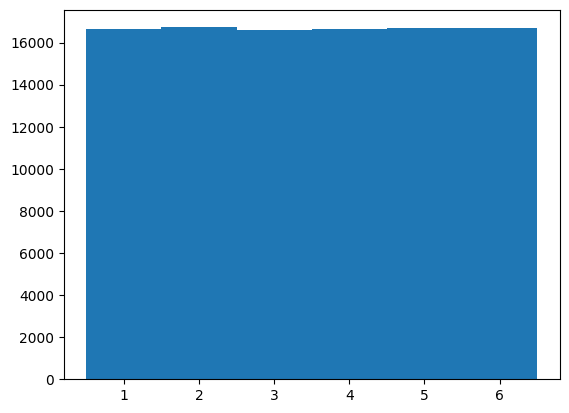

In [93]:
N = 100000
wuerfeln = np.random.randint(1,7,size=N)
%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(wuerfeln,bins=np.arange(0.5,7.5,1))
plt.show()

Das Histogramm zeigt wie erwartet eine gleichmäßig verteilte Häufigkeitsverteilung.

Mit den folgenden Befehlen wird ein Histogramm erstellt und angezeigt:

```Python
%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(wuerfeln,bins=np.arange(0.5,7.5,1))
plt.show()
```

Dies werden wir im Verlauf der Vorlesung noch genauer behandeln.

In [104]:
my_seed3 = 10
rng_3 = np.random.default_rng(my_seed3)

Einmal würfeln

In [105]:
wuerfel = rng_3.integers(1,7)
wuerfel

np.int64(5)

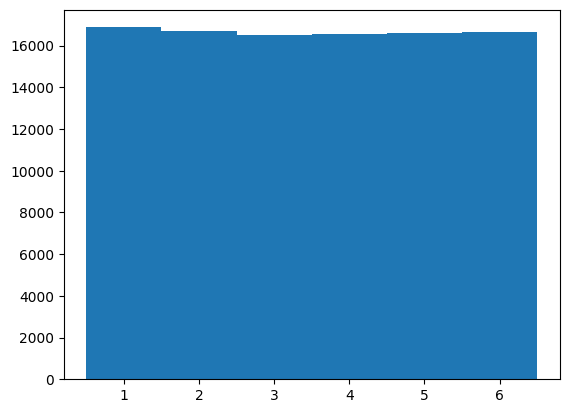

In [106]:
N = 100000
wuerfeln = np.random.default_rng(my_seed3).integers(1,7,size=N)
%matplotlib inline
import matplotlib.pyplot as plt
plt.hist(wuerfeln,bins=np.arange(0.5,7.5,1))
plt.show()

----
### Arithmetik mit _Numpy Arrays_

Referenz:
- https://www.python-kurs.eu/matrix_arithmetik.php

Zwei Array `a` und `b` erzeugen:

In [107]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [108]:
b = np.arange(9,-1,-1)
b

array([9, 8, 7, 6, 5, 4, 3, 2, 1, 0])

elementweise **Addition** zweier Arrays

In [109]:
a+b

array([9, 9, 9, 9, 9, 9, 9, 9, 9, 9])

elementweise **Subtraktion** eines Array mit einem anderen

In [110]:
a-b

array([-9, -7, -5, -3, -1,  1,  3,  5,  7,  9])

elementweise **Multiplation** zweier Arrays

In [111]:
a*b

array([ 0,  8, 14, 18, 20, 20, 18, 14,  8,  0])

elementweise **Division** zweier Arrays

In [112]:
a/b

C:\Users\guecker\AppData\Local\Temp\ipykernel_4420\1348051284.py:1: RuntimeWarning: divide by zero encountered in divide
  a/b


array([0.        , 0.125     , 0.28571429, 0.5       , 0.8       ,
       1.25      , 2.        , 3.5       , 8.        ,        inf])

Anmerkung _Division durch Null_:
Eine Division durch Null erzeugt eine RuntimeWarning.
Das Ergebnis einer Division durch Null ergibt `np.inf` bzw. `-np.inf`.

In [113]:
a//b

C:\Users\guecker\AppData\Local\Temp\ipykernel_4420\2860853455.py:1: RuntimeWarning: divide by zero encountered in floor_divide
  a//b


array([0, 0, 0, 0, 0, 1, 2, 3, 8, 0])

elementweise **Modulo-Operation** zweier Arrays

In [114]:
a%b

C:\Users\guecker\AppData\Local\Temp\ipykernel_4420\1820107994.py:1: RuntimeWarning: divide by zero encountered in remainder
  a%b


array([0, 1, 2, 3, 4, 1, 0, 1, 0, 0])

elementweise **Potenzieren** zweier Arrays

In [115]:
a**b

array([   0,    1,  128,  729, 1024,  625,  216,   49,    8,    1])

Was passiert, wenn die Dimension der beteiligten Array nicht zueinander passt?

Dann gibt es einen _ValueError_.

In [116]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [117]:
b = np.arange(9)
b

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [118]:
a+b

ValueError: operands could not be broadcast together with shapes (10,) (9,) 

----
### Broadcasting - "Einer für alle"

Addition, Subtraktion, Multiplikation, Division, Potenzieren mit einer Konstanten


In [119]:
a+100

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109])

In [120]:
a-2

array([-2, -1,  0,  1,  2,  3,  4,  5,  6,  7])

In [121]:
a*10

array([ 0, 10, 20, 30, 40, 50, 60, 70, 80, 90])

In [122]:
a/10

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])

In [123]:
1/a

C:\Users\guecker\AppData\Local\Temp\ipykernel_4420\261954055.py:1: RuntimeWarning: divide by zero encountered in divide
  1/a


array([       inf, 1.        , 0.5       , 0.33333333, 0.25      ,
       0.2       , 0.16666667, 0.14285714, 0.125     , 0.11111111])

RuntimeWarning: divide by zero encountered in divide 1/a

In [125]:
2**a

array([  1,   2,   4,   8,  16,  32,  64, 128, 256, 512])

------
### Matrix-Multiplikation

[`np.matmul(a,b)`](https://numpy.org/doc/stable/reference/generated/numpy.matmul.html)

Matrix `A` mal Vektor `b`

In [126]:
A = np.array([[1, 0],
              [0, 2]])

b = np.array([1, 2])

np.matmul(A, b)

array([1, 4])

Bei `np.matmul(a,b)` dürfen Vektor und Matrix vertauscht werden, was bei der Matrizenrechnung in der Mathematik nicht erlaubt ist:

In [127]:
np.matmul(b, A)

array([1, 4])

Matrix `A` mal Matrix `B`

In [128]:
A = np.array([[1, 0],
              [0, 2]])

B = np.array([[4, 1],
              [2, 2]])

np.matmul(A, B)

array([[4, 1],
       [4, 4]])

#### Skalarprodukt (engl. Dot product)

[`np.dot(a,b)`](https://numpy.org/doc/stable/reference/generated/numpy.dot.html)

In [129]:
a = np.array([1,2,3])
b = np.array([-7,8,9])
np.dot(a,b)

np.int64(36)

#### Kreuzprodukt / Vektorprodukt (engl. cross product)

[`np.cross(a,b)`](https://numpy.org/doc/stable/reference/generated/numpy.cross.html)

In [130]:
a = np.array([1,0,0])
b = np.array([0,1,0])
np.cross(a,b)

array([0, 0, 1])

Bei einem Vertauschen von `a` und `b` wechsel das Vorzeichen.

In [131]:
np.cross(b,a)

array([ 0,  0, -1])

#### `@`-Operator

Der `@`-Operator, verfügbar seit Python 3.5, kann für die gewöhnliche Matrixmultiplikation eingesetzt werden, 
siehe auch [numpy for matlab users](https://numpy.org/devdocs/user/numpy-for-matlab-users.html).


In [132]:
a = np.array([1,2,3])
b = np.array([-7,8,9])
a@b, np.dot(a,b)

(np.int64(36), np.int64(36))

In [133]:
A = np.array([[1, 0],
              [0, 2]])
B = np.array([[4, 1],
              [2, 2]])
b = np.array([1, 2])

A@b, np.matmul(A, b)

(array([1, 4]), array([1, 4]))

In [135]:
b@A, np.matmul(b, A)

(array([1, 4]), array([1, 4]))

In [136]:
A@B, np.matmul(A, B)

(array([[4, 1],
        [4, 4]]),
 array([[4, 1],
        [4, 4]]))

----
### _Numpy Array_ - Methoden und Attribute


#### Ändern der Array-Gestalt - [`.reshape()`](https://numpy.org/devdocs/reference/generated/numpy.ndarray.reshape.html) - Methode

Mit der  [`.reshape()`](https://numpy.org/devdocs/reference/generated/numpy.ndarray.reshape.html)-Methode kann die Gestalt (shape) des Arrays in Form von Anzahl und Größe der Dimensionen verändert werden, wenn die Anzahl der Elemente im Array gleich bleibt.

Es wird nur die Ansicht (view) auf die Elemente geändert, jedoch nicht die Anordnung der Element im Speicher. Die Elemente bleiben, wo sie sind; die Elemente werden nicht kopiert.

Der [`.reshape()`](https://numpy.org/devdocs/reference/generated/numpy.ndarray.reshape.html)-Methode wird ein Tupel übergeben, was die neuen Dimensionen des Arrays enthält.
 
Wir erzeugen uns zuerst ein 1D _Numpy Array_ mit 24 Elementen:

In [137]:
a = np.arange(1,25)
print(f'shape: {a.shape}')
a

shape: (24,)


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

Die 24 Elemente wollen wir jetzt als 2D _Numpy Array_ mit 6 Zeilen und 4 Spalten darstellen:

In [138]:
a2 = a.reshape((6,4))
print(f'shape: {a2.shape}')
a2

shape: (6, 4)


array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20],
       [21, 22, 23, 24]])

Jetzt wollen wir es als 2D _Numpy Array_ mit 3 Zeilen und 8 Spalten darstellen:

In [139]:
a3 = a.reshape((3,8))
print(f'shape: {a3.shape}')
a3

shape: (3, 8)


array([[ 1,  2,  3,  4,  5,  6,  7,  8],
       [ 9, 10, 11, 12, 13, 14, 15, 16],
       [17, 18, 19, 20, 21, 22, 23, 24]])

`a` bleibt unverändert - aber Elemente werden gemeinsam genutzt 

wir können es auch al3 3D _Numpy Array_ mit der Dimension 2,3 und 4 darstellen

In [140]:
a4 = a.reshape((2,3,4))
print(f'shape: {a4.shape}')
a4

shape: (2, 3, 4)


array([[[ 1,  2,  3,  4],
        [ 5,  6,  7,  8],
        [ 9, 10, 11, 12]],

       [[13, 14, 15, 16],
        [17, 18, 19, 20],
        [21, 22, 23, 24]]])

Beispiel: Erzeugen eines 2D-Arrays mit aufsteigenden Zahlen 

In [141]:
np.arange(1,33).reshape((8,4))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12],
       [13, 14, 15, 16],
       [17, 18, 19, 20],
       [21, 22, 23, 24],
       [25, 26, 27, 28],
       [29, 30, 31, 32]])

-----
#### Minimum und Maximum - `.min()`, `.max()`, `.argmin()`und `.argmax()`

- `.min()` und `.max()`    -> Minimal- und Maximalwert
- `.argmin()`und `.argmax()` -> Index des Minimal- und Maximalwert

Im Falle, dass der Mininmal- oder Maximalwert mehrmals auftritt, liefern `.argmin()` und `.argmax()` den Index des ersten auftretenden Wertes.

In [144]:
a = np.array([2, -10, -10, 8, -5,3])
a

array([  2, -10, -10,   8,  -5,   3])

In [145]:
a.max()

np.int64(8)

In [146]:
a.min()

np.int64(-10)

```python
array([  2, -10,  -10,   8,  -5,   3])
Index    0    1    2    3    4    5
```

In [147]:
a.argmax()

np.int64(3)

In [148]:
a.argmin()

np.int64(1)

---
### UFunc - universelle Funktionen

Funktionen, die auf die einzelnen Werte angewendet werden

Referenz:
[ufuncs - numpy](https://numpy.org/doc/stable/reference/ufuncs.html)

Wir erzeugen un einen Numpy Array mit 10 Elementen:

In [149]:
a = np.arange(10)
a

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

#### Quadratwurzel [`sqrt(a)`](https://numpy.org/devdocs/reference/generated/numpy.sqrt.html)

In [150]:
np.sqrt(a)

array([0.        , 1.        , 1.41421356, 1.73205081, 2.        ,
       2.23606798, 2.44948974, 2.64575131, 2.82842712, 3.        ])

#### trigonometrische Funktionen 

Beispiel: Sinus-Funktion [`sin(a)`](https://numpy.org/devdocs/reference/generated/numpy.sin.html)

In [151]:
np.sin(a)

array([ 0.        ,  0.84147098,  0.90929743,  0.14112001, -0.7568025 ,
       -0.95892427, -0.2794155 ,  0.6569866 ,  0.98935825,  0.41211849])

#### Exponential-Funktion [`exp(a)`](https://numpy.org/devdocs/reference/generated/numpy.exp.html)

In [152]:
np.exp(a)

array([1.00000000e+00, 2.71828183e+00, 7.38905610e+00, 2.00855369e+01,
       5.45981500e+01, 1.48413159e+02, 4.03428793e+02, 1.09663316e+03,
       2.98095799e+03, 8.10308393e+03])

#### natürlicher Logrithmus [`log(a)`](https://numpy.org/devdocs/reference/generated/numpy.log.html)

In [153]:
np.log(a)

C:\Users\guecker\AppData\Local\Temp\ipykernel_4420\176755284.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(a)


array([      -inf, 0.        , 0.69314718, 1.09861229, 1.38629436,
       1.60943791, 1.79175947, 1.94591015, 2.07944154, 2.19722458])

----
### Konstanten $\pi$ und $e$

Referenz:

[Constants - numpy](https://numpy.org/devdocs/reference/constants.html)

In [154]:
np.pi

3.141592653589793

In [155]:
np.e

2.718281828459045

Not-a-number 

In [156]:
np.nan

nan

In [157]:
type(np.nan)

float

In [158]:
np.log(-1)

C:\Users\guecker\AppData\Local\Temp\ipykernel_4420\153577755.py:1: RuntimeWarning: invalid value encountered in log
  np.log(-1)


np.float64(nan)

In [159]:
np.float64(np.nan)

np.float64(nan)

In [160]:
type(np.float64(np.nan))

numpy.float64

Unterschied zwischen `np.nan` und `np.float64(np.nan)`

+ `np.nan` -->  Python-Float
   + ist ein NaN-Wert als Python-`float`
   + entspricht `float("nan")`
   + sein Typ ist `float`
   + Beispiel: `type(np.nan) -> <class 'float'>`
   
+ `np.float64(np.nan)` --> NumPy-Float64-Skalar
   + ist ein NumPy-Skalar vom Typ np.float64
   + enthält denselben NaN-Wert, aber mit NumPy-Datentyp
   + Beispiel: `type(np.float64(np.nan)) -> <class 'numpy.float64'>`

inifinty

In [161]:
np.inf

inf

In [162]:
np.array([1])/np.array([0])

C:\Users\guecker\AppData\Local\Temp\ipykernel_4420\1478048614.py:1: RuntimeWarning: divide by zero encountered in divide
  np.array([1])/np.array([0])


array([inf])

---
### Datentyp eines NumPy Arrays

Wenn alle Elemente eines _Numpy Arrays_ nur ganze Zahlen sind, reicht der Datentyp _Integer_ `int64`:

In [163]:
a = np.array([1,2,3,4,5])
a.dtype

dtype('int64')

Wenn eine Fließkommazahl dabei ist, muss _Fließkomma_ `float64` muss als Datentyp gewählt werden.

In [164]:
a = np.array([1,2,3,4,5.5])
a.dtype

dtype('float64')

Wenn eine komplexe Zahl (`j` ist die imaginären Einheit) dabei ist, wird als Datentyp `complex128` gewählt.

In [165]:
a = np.array([1,2,3,5,5.5+7j])
a.dtype

dtype('complex128')

Beim Erzeugen des _Numpy Arrays_ kann der Datentyp durch `dtype=<datentyp>` festgelegt werden:

Referenz für Datentype: [Data Types - numpy](https://numpy.org/doc/stable/user/basics.types.html)


In [166]:
a = np.array([1,2,3,4,5.6, -6.7], dtype='int32')
a.dtype

dtype('int32')

Fließkomma werden in Integer gewandelt; die Nachkommastellen werden einfach geschnitten!!!

In [167]:
a

array([ 1,  2,  3,  4,  5, -6], dtype=int32)

#### Typumwandlung mit `.astype()`

Um ein Integer-NumPy-Array in ein Float-NumPy-Array umzuwandeln, kannst du die Methode `.astype()` verwenden. Diese Methode erstellt eine neue Kopie des Arrays mit dem gewünschten Datentyp.

In [168]:
a_float32 = a.astype('float32')
a_float32 

array([ 1.,  2.,  3.,  4.,  5., -6.], dtype=float32)

In [169]:
a_float32.dtype

dtype('float32')

In [170]:
a_float64 = a.astype('float64')
a_float64 

array([ 1.,  2.,  3.,  4.,  5., -6.])

In [171]:
a_float64.dtype

dtype('float64')

----
### Zugriff auf die Elemente des Arrays (Indexing)

```
    Array            1  2  3  4  5
    Index vorwärts   0  1  2  3  4  
    Index rückwärts -5 -4 -3 -2 -1  

```

In [172]:
a = np.array([1,2,3,4,5])

Lesezugriff

erstes Element

In [173]:
a[0]

np.int64(1)

letztes Element

In [174]:
a[4]

np.int64(5)

In [175]:
a[-1]

np.int64(5)

alternativer Zugriff auf Anfang des Arrays (für dieses Beispiel)

In [176]:
a[-5]

np.int64(1)

#### Zugriff außerhalb der zulässigen Grenzen

Zugriff mit einem Index der nicht im Array liegt, bringt eine `IndexError`-Fehlermeldung hervor:

In [177]:
a[5]

IndexError: index 5 is out of bounds for axis 0 with size 5

Schreibzugriff

In [178]:
a[2]=10
a

array([ 1,  2, 10,  4,  5])

In [179]:
a[2]=[10,11]

TypeError: int() argument must be a string, a bytes-like object or a real number, not 'list'

#### Vorsicht bei Referenzen !!!

In [180]:
a = np.array([1,2,3,4,5])
a

array([1, 2, 3, 4, 5])

Variable `b` wird `a` zugewiesen

In [181]:
b = a
b

array([1, 2, 3, 4, 5])

jetzt wird ein Element von `b` verändert

In [182]:
b[2] = 10
b

array([ 1,  2, 10,  4,  5])

In [183]:
a

array([ 1,  2, 10,  4,  5])

und `a` verändert sich mit:

In [184]:
print(f'a = {a}, \t id(a) = {id(a)}')
print(f'b = {b}, \t id(b) = {id(b)}')

a = [ 1  2 10  4  5], 	 id(a) = 1452518887408
b = [ 1  2 10  4  5], 	 id(b) = 1452518887408


`a` wird mit verändert.
<br>
Bei der Zuweisung `b=a` wird eine Referenz aber keine Kopie angelegt.

Jetzt wird `b` als Kopie `a` mit der `.copy()`-Methode angelegt:

In [185]:
a = np.array([1,2,3,4,5])
b = a.copy()

b[2] = 10

print(f'a = {a}, \t id(a) = {id(a)}')
print(f'b = {b}, \t id(b) = {id(b)}')

a = [1 2 3 4 5], 	 id(a) = 1452518888848
b = [ 1  2 10  4  5], 	 id(b) = 1452518889808


Referenzen bei Integer - immutable Objekt

In [186]:
zahl_a = 10

In [187]:
zahl_b = zahl_a

In [188]:
print(f'zahl_a = {zahl_a}, \t id(zahl_a) = {id(zahl_a)}')
print(f'zahl_b = {zahl_b}, \t id(zahl_b) = {id(zahl_b)}')

zahl_a = 10, 	 id(zahl_a) = 140716951399128
zahl_b = 10, 	 id(zahl_b) = 140716951399128


`zahl_a` und `zahl_b` zeigen auf dasselbe Objekt.

In [189]:
zahl_b = 11

neues Objekt 11 angelegt und `zahl_b` zeigt jetzt auf dieses neue Objekt.

In [190]:
print(f'zahl_a = {zahl_a}, \t id(zahl_a) = {id(zahl_a)}')
print(f'zahl_b = {zahl_b}, \t id(zahl_b) = {id(zahl_b)}')

zahl_a = 10, 	 id(zahl_a) = 140716951399128
zahl_b = 11, 	 id(zahl_b) = 140716951399160


In [ ]:
# es gibt kein copy bei Integer
#zahl_c = zahl_a.copy()

---
## NumPy Arrays mit mehreren Dimensionen

- axis=0 -> vertikal -> Zeilen
- axis=1 -> horizontal -> Spalten

In [191]:
matrix = np.array([ [11,12,13,14], [21,22,23,24],[31,32,33,34]])
matrix

array([[11, 12, 13, 14],
       [21, 22, 23, 24],
       [31, 32, 33, 34]])

In [192]:
matrix.ndim

2

Anzahl der Zeilen, Anzahl der Spalten

In [193]:
matrix.shape

(3, 4)

erste Zeile - partial Indexing (Anzahl der Indeces < Anzahl der Dimensionen)

In [194]:
matrix[0]

array([11, 12, 13, 14])

Element in der ersten Zeile und ersten Spalte 

In [195]:
matrix[0][1]

np.int64(12)

In [196]:
matrix[0,1]

np.int64(12)

Element in der dritten Zeile und zweiten Spalte 

In [197]:
matrix[2,1]

np.int64(32)

Zweite Spalte

In [198]:
matrix[:,1]

array([12, 22, 32])

nicht das gleiche wie matrix[:][1] - das ist ein häufiger Fehler
matrix[:, 1]

In [201]:
matrix[:][1]

array([21, 22, 23, 24])

----
## Ausschnitte von Arrays (Slicing) 

ähnlich wie bei Listen und Zeichenketten

```
    Array            1  2  3  4  5
    Index vorwärts   0  1  2  3  4  
    Index rückwärts -5 -4 -3 -2 -1  

```

In [202]:
a = np.array([1,2,3,4,5])
a

array([1, 2, 3, 4, 5])

Syntax `[AnfangsIndex:EndIndex:Schrittweite]`

**EndIndex** ist nicht enthalten !!!

In [203]:
a[1:3]

array([2, 3])

negative Indices - zählen vom Ende des Arrays

In [204]:
a[1:-2]

array([2, 3])

Auslassen von Indices -> geläufige Muster (Patterns)

StartIndex auslassen -> wird als 0 gewertet

In [205]:
a[0:3]

array([1, 2, 3])

In [206]:
a[:3]

array([1, 2, 3])

EndIndex auslassen -> Elemente vom StartIndex bis zum Ende des Arrays ausgeben

"Gebe mir die letzten beiden Elemente des Arrays zurück"

In [207]:
a[-2:]

array([4, 5])

In [208]:
a[-2:5]

array([4, 5])

"Gebe mir jedes zweite Element des Array"

In [209]:
a[::2]

array([1, 3, 5])

nur die geraden Zahlen:

In [210]:
a[1::2]

array([2, 4])

negative Schrittweite
```
    Array            1  2  3  4  5
    Index vorwärts   0  1  2  3  4  
    Index rückwärts -5 -4 -3 -2 -1  

```

In [211]:
a[-2:-5:-1]

array([4, 3, 2])

Reihenfolge des Arrays umkehren

In [212]:
a[::-1]

array([5, 4, 3, 2, 1])

In [213]:
a[4:-6:-1]

array([5, 4, 3, 2, 1])

-----
### Indexieren und Slicing in mehrdimensionalen Arrays

**Indexieren** vermindert die Dimension

**Slicing** erhält die Dimension

In [214]:
a = np.arange(1,37).reshape((6,6))
a

array([[ 1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18],
       [19, 20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29, 30],
       [31, 32, 33, 34, 35, 36]])

erste Zeile

In [215]:
a[0]

array([1, 2, 3, 4, 5, 6])

unterste Zeile

In [216]:
a[-1]

array([31, 32, 33, 34, 35, 36])

erste Zeile und zweite und dritte Spalte

In [217]:
a[0,1:3]

array([2, 3])

komplette vierte Spalte

In [219]:
a[:,3]

array([ 4, 10, 16, 22, 28, 34])

vorletzte Spalte

In [220]:
a[:,-2]

array([ 5, 11, 17, 23, 29, 35])

ab fünfter Zeile bis Ende und ab vierter Spalte bis Ende 

In [221]:
a[4:,3:]

array([[28, 29, 30],
       [34, 35, 36]])

jede zweite Zeile beginnend bei ersten Zeile und
<br>
und
<br>
jede dritte Spalte beginnend bei der ersten Spalte

In [222]:
a[::2,::3]

array([[ 1,  4],
       [13, 16],
       [25, 28]])

jede zweite Zeile beginnend bei zweiten Zeile und
<br>
und
<br>
jede dritte Spalte beginnend bei der dritten Spalte

In [223]:
a[1::2,2::3]

array([[ 9, 12],
       [21, 24],
       [33, 36]])

#### Vorsicht bei Referenzen !!!

In [224]:
b = a[:3]
b

array([[ 1,  2,  3,  4,  5,  6],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18]])

In [225]:
b[0] = 10
b

array([[10, 10, 10, 10, 10, 10],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18]])

In [226]:
a

array([[10, 10, 10, 10, 10, 10],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18],
       [19, 20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29, 30],
       [31, 32, 33, 34, 35, 36]])

Um ein _Numpy Array_ verändern zu können, ohne dass das ursprüngliche verändert wird, muss eine Kopie mit der [`.copy()`](https://numpy.org/devdocs/reference/generated/numpy.copy.html)-Methode erstellt werden:

In [227]:
b2 = a[:3].copy()
b2

array([[10, 10, 10, 10, 10, 10],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18]])

`b2` ist jetzt eine Kopie, die wir verändern können, ohne `a` zu verändern:

In [228]:
b2[0]=1

In [229]:
b2

array([[ 1,  1,  1,  1,  1,  1],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18]])

erste Zeile in `b` wurde mit Einsen überschrieben

In [230]:
a

array([[10, 10, 10, 10, 10, 10],
       [ 7,  8,  9, 10, 11, 12],
       [13, 14, 15, 16, 17, 18],
       [19, 20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29, 30],
       [31, 32, 33, 34, 35, 36]])

`a` bleibt unverändert

----
### Mask Arrays

**Aufgabe:** Wir wollen die Elemente in einem _Numpy Array_ nach bestimmten Bedingingen herausholen; z.B. alle Elemente die größer als 3 sind.

Dazu erzeugen wir uns zunächst folgendes _Numpy Array_:

In [231]:
a = np.array([1,2,3,4,5])
a

array([1, 2, 3, 4, 5])

Jetzt erzeugen wir ein gleich großes Array mit boolschen Werten der Bedinging Element größer 3:

In [232]:
a>3

array([False, False, False,  True,  True])

Dies ist verwenden wir jetzt als eine Art Maske zum 'Herausstanzen' der Werte, die die Bedingung erfüllen:

In [233]:
mask = a>3
a[mask]

array([4, 5])

Das zurückgegeben Array enthält jetzt nur die Elemente, die die Bedingung `a` größer als 3 erfüllen.

Das Erzeugen der Mask und das Selektieren kann auch in einer Zeile erfolgen:

In [234]:
a[a>3]

array([4, 5])

Bei Anwenden der Maske mit der Bedingung, wird ein neues _Numpy Array_ erzeugt:

In [235]:
a = np.array([1,2,3,4,5])
b=a[a>3]   # -> Mask array -> neues Objekt
c=a[-2:]   # -> Slicing -> Referenz auf das ursprüngliche Objekt

print(f"{a=}")
print(f"{b=} {np.shares_memory(a,b)=}")
print(f"{c=} {np.shares_memory(a,c)=}")

a=array([1, 2, 3, 4, 5])
b=array([4, 5]) np.shares_memory(a,b)=False
c=array([4, 5]) np.shares_memory(a,c)=True


In [236]:
b[0] = 10
c[1] = 11

print(f"{a=}")
print(f"{b=} {np.shares_memory(a,b)=}")
print(f"{c=} {np.shares_memory(a,c)=}")

a=array([ 1,  2,  3,  4, 11])
b=array([10,  5]) np.shares_memory(a,b)=False
c=array([ 4, 11]) np.shares_memory(a,c)=True


_Hinweis:_
Du kannst überprüfen, ob zwei Arrays denselben Speicherbereich teilen, indem du die Methode 
`np.shares_memory(a, b)` verwendest. 
Gibt diese Funktion True zurück, teilen sich a und b Speicher – was typischerweise beim Slicing der Fall ist.

#### Komplexere Bedingungen aufbauen

Verknüpfung mehrerer Bedingungen mit:

- und `&`
- oder `|`
- negieren `~`

Runde Klammern verwenden und die Element der Bedingung klar zu markieren.

Bedingung `a` größer als 2  und a kleiner als 5

In [237]:
cond = (a>2) & (a<5)
cond

array([False, False,  True,  True, False])

Bedingungen in Klammern, sonst gibt es `ValueError`-Fehler

In [238]:
cond = a>2 & a<5

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

In [239]:
a[cond]

array([3, 4])

In [240]:
a[(a>2) & (a<5)]

array([3, 4])

[De-morgansche Gesetze](https://de.wikipedia.org/wiki/De-morgansche_Gesetze)

    nicht (a und b) ist äquivalent zu ((nicht a) oder (nicht b))
    nicht (a oder b) ist äquivalent zu ((nicht a) und (nicht b))

In [241]:
cond = ~(~(a>2) | ~(a<5))
print(cond)
print(a[cond])

[False False  True  True False]
[3 4]


In [242]:
cond = ~((a<=2) | (a>=5))
print(cond)
print(a[cond])

[False False  True  True False]
[3 4]


----
#### Anwendungen von Mask-Arrays


Beispiel: Zählen der True-Wert in einem Mask Array durch Berechnen der Summe:

In [243]:
mask = np.array([True, False, True,True,False])
mask

array([ True, False,  True,  True, False])

Funktion sum aus dem Numpy Paket:

In [244]:
np.sum(mask)

np.int64(3)

Summe als Methode des Objekt mask.

In [245]:
mask.sum()

np.int64(3)

Mittelwert - relative Aussage

In [246]:
np.mean(mask)

np.float64(0.6)

In [247]:
mask.mean()

np.float64(0.6)

Beispiel: Wieviel der Zufallszahlen einer gleichförmige Verteilung zwischen [0, 1) [`rand()`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html) sind größer als 0.5?




In [248]:
N = 10000
a = np.random.rand(N)

mask = a>0.5
mask.sum()

np.int64(4930)

In [249]:
(a>0.5).sum()

np.int64(4930)

Mittelwert

In [250]:
a.mean()

np.float64(0.4951810144753308)

Median

In [ ]:
np.median(a)